In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import mlflow
import mlflow.pytorch
import os
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load label encoder
with open('../data/processed/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)
CLASS_NAMES = le.classes_.tolist()
print(f"Classes: {CLASS_NAMES}")

Using device: cpu
Classes: [np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]


In [2]:
TARGET_SIZE = 64

class WaferDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wafer = row['waferMap'].astype(np.float32)
        label = int(row['label_encoded'])
        
        img = Image.fromarray(wafer)
        img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.NEAREST)
        wafer_resized = np.array(img)
        
        wafer_norm = wafer_resized / 2.0
        tensor = torch.FloatTensor(wafer_norm).unsqueeze(0)
        tensor = tensor.repeat(3, 1, 1)
        
        if self.transform:
            tensor = self.transform(tensor)
        return tensor, label

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=30),
])

train_df = pd.read_pickle('../data/processed/train.pkl')
val_df   = pd.read_pickle('../data/processed/val.pkl')
test_df  = pd.read_pickle('../data/processed/test.pkl')

BATCH_SIZE = 64
train_loader = DataLoader(WaferDataset(train_df, transform=train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(WaferDataset(val_df),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(WaferDataset(test_df),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train: 2162 batches | Val: 271 | Test: 271


Why ResNet18 specifically for your wafer project?
A few reasons that connect directly to your work:

ResNet18 = 18 layers, ~11.7M parameters. Powerful but not overkill for 64×64 images.

It was pretrained on ImageNet (1.2M natural images). The early layers already know how to detect edges, curves, shapes — exactly what wafer defect patterns are made of.

You only replaced the final classification layer (1000 ImageNet classes → 9 defect classes). Everything else was already learned.

ResNet adds shortcut connections that let the gradient flow directly to earlier layers without passing through nonlinearities, which solves the vanishing gradient problem and makes deep networks trainable." That's the whole thing.

In [4]:
def build_resnet18(num_classes):
    model = models.resnet18(weights='IMAGENET1K_V1')
    # Replace final FC layer for our 9 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_resnet18(NUM_CLASSES).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable:,}")
print(f"\nModel output shape test:")
dummy = torch.randn(4, 3, 64, 64).to(device)
print(f"  Input:  {dummy.shape}")
print(f"  Output: {model(dummy).shape}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/sairohitabhaskaruni/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:23<00:00, 2.00MB/s]


Total params:     11,181,129
Trainable params: 11,181,129

Model output shape test:
  Input:  torch.Size([4, 3, 64, 64])
  Output: torch.Size([4, 9])


What is an optimizer?
When your model makes a prediction and gets it wrong, you need to update the model's weights to make it less wrong next time. The optimizer is the thing that decides how to update those weights.<br><br>
Think of it like this: imagine you're blindfolded on a hilly landscape and you're trying to find the lowest point (the lowest loss). You can't see anything, but you can feel the slope under your feet. The optimizer decides: which direction do I step, and how big a step do I take?<br>
The "slope" it feels is the gradient — calculated by backpropagation. The optimizer uses that gradient to update every single one of the 11 million weights in ResNet18.<br>
Why Adam specifically?<br>
The simplest optimizer is just "step downhill by a fixed amount every time" — that's called SGD (Stochastic Gradient Descent). Adam is smarter than that. It keeps track of how much each individual weight has been changing recently, and adjusts the step size per weight accordingly. Weights that have been getting large gradients get smaller steps. Weights that rarely update get larger steps. It adapts — that's why it's called Adam (Adaptive Moment estimation). <br>
In practice: Adam converges faster and is more forgiving if your learning rate isn't perfectly tuned. That's why it's the default choice for most projects.

What is a scheduler?

Going back to the blindfolded-on-a-hill analogy: imagine you start with big steps to cover ground quickly, but as you get closer to the bottom, big steps start making you overshoot. You'd want to take smaller and smaller steps as you near the goal.

That's what a learning rate scheduler does — it automatically reduces the learning rate over time.

Why ReduceLROnPlateau?
Your scheduler watches the validation loss. If it doesn't improve for 3 epochs in a row (patience=3), it cuts the learning rate in half (factor=0.5). You can see this playing out in your actual training 

output:
Epoch 03: val_loss=0.4677  ← improving

Epoch 04: val_loss=0.5146  ← worse (1)

Epoch 05: val_loss=1.5535  ← worse (2), spike!

Epoch 06: val_loss=0.5446  ← worse (3) → scheduler fires, LR halved

Epoch 07: val_loss=0.3801  ← improving again ✓

After the LR gets halved, the model stops overshooting and starts making progress again. The scheduler basically says "you seem to be stuck, take smaller steps."

outputs = model(images)        # forward pass: make predictions

loss = criterion(outputs, labels)  # calculate how wrong we are

loss.backward()                # backprop: calculate gradients (the slope)

optimizer.step()               # Adam uses gradients to update weights

scheduler.step(val_loss)       # after each epoch: maybe shrink the LR

In [8]:
# Weighted cross entropy to handle class imbalance
class_weights = torch.load('../data/processed/class_weights.pt').to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# LR scheduler - reduce on plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print("Criterion:", criterion)
print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Criterion: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x15a5185d0>


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print("Training functions defined.")

Training functions defined.


In [17]:
model = build_resnet18(NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print("Model reinitialized.")

Model reinitialized.


In [18]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

mlflow.set_experiment("wafer-baseline-resnet18")

with mlflow.start_run(run_name="resnet18_weighted_ce_v2"):
    mlflow.log_params({
        "model": "resnet18",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "adam",
        "lr": 1e-3,
        "loss": "weighted_cross_entropy",
        "image_size": TARGET_SIZE
    })
    
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        # Save checkpoint every 5 epochs automatically
        if (epoch + 1) % 5 == 0:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'epoch': epoch + 1,
                'best_val_loss': best_val_loss
            }, f'../data/processed/checkpoint_epoch{epoch+1}.pt')
            print(f"  → Checkpoint saved at epoch {epoch+1}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '../data/processed/best_resnet18.pt')
            print(f"Epoch {epoch+1:02d}/{EPOCHS} ✓ BEST | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")
        else:
            print(f"Epoch {epoch+1:02d}/{EPOCHS}        | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")

print("Training complete!")

Epoch 01/20 ✓ BEST | train_loss=0.9501 acc=0.736 | val_loss=0.6774 acc=0.802


Epoch 02/20 ✓ BEST | train_loss=0.5982 acc=0.822 | val_loss=0.4838 acc=0.829


Epoch 03/20 ✓ BEST | train_loss=0.5492 acc=0.832 | val_loss=0.4677 acc=0.863


Epoch 04/20        | train_loss=0.4655 acc=0.860 | val_loss=0.5146 acc=0.866


  → Checkpoint saved at epoch 5
Epoch 05/20        | train_loss=0.4545 acc=0.862 | val_loss=1.5535 acc=0.922


...

Epoch 16/20        | train_loss=0.2549 acc=0.910 | val_loss=0.2565 acc=0.925


Epoch 17/20        | train_loss=0.2442 acc=0.914 | val_loss=0.2957 acc=0.915


Epoch 18/20        | train_loss=0.2424 acc=0.913 | val_loss=0.2597 acc=0.951


Epoch 19/20        | train_loss=0.2455 acc=0.913 | val_loss=0.3041 acc=0.957


  → Checkpoint saved at epoch 20
Epoch 20/20 ✓ BEST | train_loss=0.2185 acc=0.920 | val_loss=0.2393 acc=0.953
Training complete!


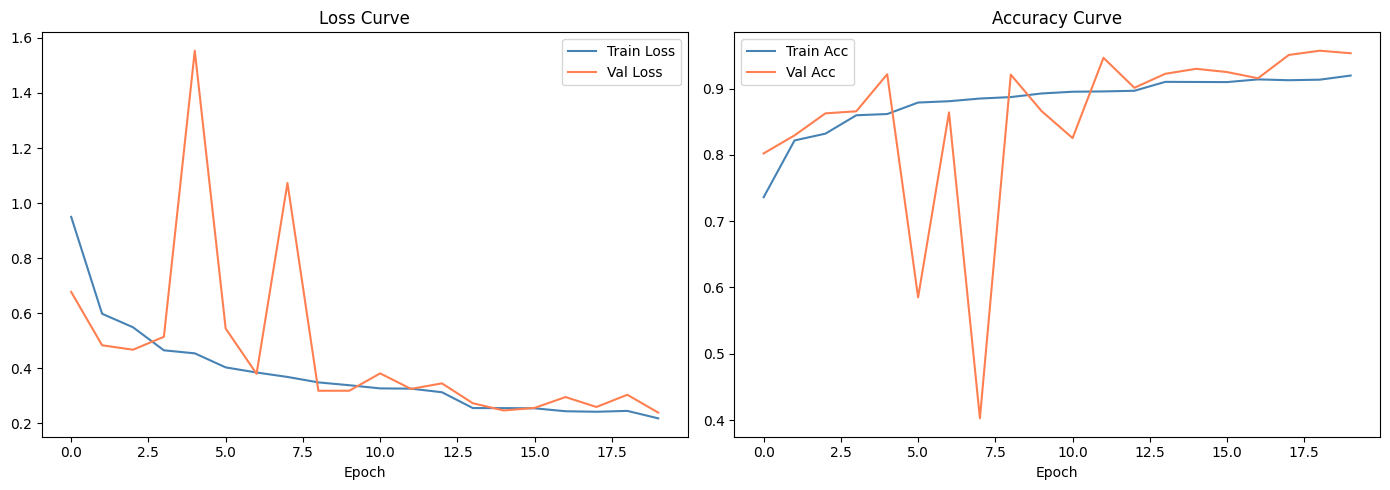

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='coral')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='coral')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/training_curves.png', dpi=150)
plt.show()

Test Accuracy: 0.9526

              precision    recall  f1-score   support

      Center       0.82      0.94      0.88       430
       Donut       0.78      0.95      0.85        55
    Edge-Loc       0.69      0.87      0.77       519
   Edge-Ring       0.95      0.98      0.96       968
         Loc       0.63      0.74      0.68       360
   Near-full       0.94      1.00      0.97        15
      Random       0.65      0.97      0.78        86
     Scratch       0.36      0.91      0.51       119
        none       1.00      0.96      0.98     14743

    accuracy                           0.95     17295
   macro avg       0.76      0.92      0.82     17295
weighted avg       0.96      0.95      0.96     17295



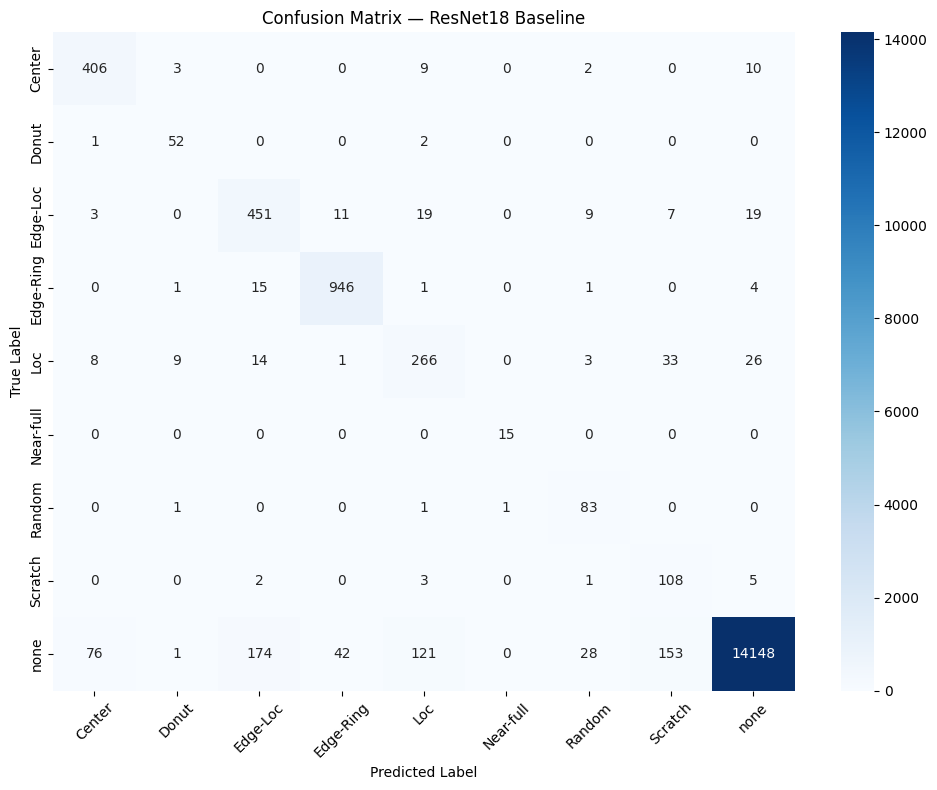

In [21]:
# Load best model
model.load_state_dict(torch.load('../data/processed/best_resnet18.pt', map_location=device))
_, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — ResNet18 Baseline')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_baseline.png', dpi=150)
plt.show()

The Loss & Accuracy curves (Image 1)<br>
The blue line (train) is smooth and steadily going down — that's exactly what you want. The orange line (val) is the problem. See those two massive spikes around epoch 5 and epoch 7? Val loss shot up to 1.55 and 1.07 while train loss was calmly at 0.45. That's the learning rate being too aggressive — the optimizer was taking steps so big it kept overshooting.<br>
This is exactly where your ReduceLROnPlateau scheduler kicked in. After seeing the val loss not improve for 3 epochs, it halved the learning rate — and after epoch 8 the orange line calms down and starts following the blue line properly.
By epoch 15-20 both lines converge around 0.22-0.24, and val accuracy actually ends above train accuracy (0.953 vs 0.920). That's a good sign — no overfitting.

But here's the important thing about "pretty good"<br>
95.26% accuracy sounds impressive. But look at the confusion matrix (Image 2) more carefully.<br>
The "none" class has 14,148 correct predictions out of 14,743 samples. That one class is so dominant it's basically carrying your accuracy number. If you predicted "none" for every single wafer, you'd get 85% accuracy doing nothing.<br>

The real story is in the off-diagonal numbers — the mistakes. Let me point out the ones that matter:

Scratch row: 108 correct, but 33 predicted as Loc, 5 as none, 2 as Edge-Loc. Only 108/119 = 91% recall. But look at the Scratch column — 153 "none" wafers were incorrectly called Scratch, 33 Loc wafers called Scratch. So when the model says "Scratch", it's wrong almost as often as it's right. That's why precision is only 36% despite decent recall.
Loc row: 266 correct out of 360, but 33 got predicted as Scratch, 26 as none, 19 as Edge-Loc. Loc and Scratch are constantly confused with each other — bidirectional.

none row: 595 "none" wafers were misclassified — 174 called Edge-Loc, 153 called Scratch, 121 called Loc, 76 called Center. The model is over-predicting defect classes on clean wafers because of the class weights pushing it.


So what does epoch 20's numbers actually mean?

train acc=0.920, val acc=0.953

Training accuracy being lower than val accuracy is slightly unusual but fine here — it's because augmentation (random flips, rotations) makes training harder, while validation sees clean unaugmented images.

The macro F1 of 0.82 is the more honest number. That averages F1 equally across all 9 classes — so Scratch's 0.51 drags it down significantly even though "none" has 0.98. Macro F1 doesn't let the dominant class hide the weak ones.

The bottom line: the model is genuinely good at Edge-Ring, Center, Near-full, and none. It's struggling with Scratch and Loc — and that's not fixable by training longer or changing the optimizer. Those two classes need a different approach, which is exactly what notebook 04 addresses.

So why penalize rare classes more if we care about all classes equally?

The answer is: class weights are not about importance, they're about fixing a sampling problem.
Here's the issue. During training, in every batch of 64 wafers, roughly:

54 are "none"

3 are Edge-Ring

1 is Center

0 or 1 is Scratch

0 Near-full wafers appear in most batches entirely

The model sees "none" examples thousands of times more than it sees Near-full. Without class weights, the optimizer barely gets any signal from rare classes — not because they're unimportant, but simply because they barely show up. The model never really learns them.
Class weights artificially compensate for this. When a Near-full wafer does appear, its loss contribution is inflated so the model pays attention and updates meaningfully. It's not saying "Near-full is more important than Scratch" — it's saying "Near-full is so rare that when we do see it, we need to make the most of it."

Think of it like studying for an exam. If 85% of the exam is on topic A and 0.1% is on topic Z, you'd naturally spend almost no time on Z. Class weights are like your professor saying "topic Z will be worth 326 points per question instead of 1 point" — not because Z is inherently more important, but to force you to actually study it.

In [10]:
EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

mlflow.set_experiment("wafer-baseline-resnet18")

with mlflow.start_run(run_name="resnet18_weighted_ce"):
    mlflow.log_params({
        "model": "resnet18",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "adam",
        "lr": 1e-3,
        "loss": "weighted_cross_entropy",
        "image_size": TARGET_SIZE
    })
    
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        mlflow.log_metrics({
            "train_loss": train_loss, "val_loss": val_loss,
            "train_acc": train_acc,   "val_acc": val_acc
        }, step=epoch)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '../data/processed/best_resnet18.pt')
            print(f"Epoch {epoch+1:02d} ✓ BEST  | train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")
        else:
            print(f"Epoch {epoch+1:02d}        | train_loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")
    
    mlflow.pytorch.log_model(model, "model")
    print("\nTraining complete. Best val loss:", round(best_val_loss, 4))

2026/04/22 19:42:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/22 19:42:55 INFO mlflow.store.db.utils: Updating database tables
2026/04/22 19:42:56 INFO mlflow.tracking.fluent: Experiment with name 'wafer-baseline-resnet18' does not exist. Creating a new experiment.


Epoch 01 ✓ BEST  | train_loss=0.9975 acc=0.7243 | val_loss=1.1386 acc=0.8694


KeyboardInterrupt: 

In [12]:
print(torch.backends.mps.is_available())

True


In [14]:
device = torch.device('mps')
print("Using Apple Metal GPU!")

Using Apple Metal GPU!


In [15]:
print("MPS:", torch.backends.mps.is_available())
print("CUDA:", torch.cuda.is_available())

MPS: True
CUDA: False


In [16]:
# Set device to Apple Metal GPU
device = torch.device('mps')
print(f"Using: {device}")

# Reinitialize model on MPS
model = build_resnet18(NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Reload class weights on correct device
class_weights = torch.load('../data/processed/class_weights.pt').to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Model reinitialized on MPS!")

Using: mps
Model reinitialized on MPS!


In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'epoch': len(history['train_loss']),
    'best_val_loss': best_val_loss
}, '../data/processed/checkpoint_resnet18.pt')

print("Checkpoint saved!")
print(f"Saved at epoch {len(history['train_loss'])}")